# Image-Based Pairwise Ranking Model for Best Fundus Image Selection

EfficientNet-B0バックボーンを使用した画像ベースのPairwise Rankingモデル。
**Lens領域のみをクロップして使用**（フル画像は使用しない）。

- 前回の結果: Feature-based MLP → 0%（失敗）、ルールベースAI → 47.3%
- 今回の目標: 画像ベースRanker → 60%以上

## Section 1: セットアップ & インポート

In [23]:
import os
import sys
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
import json

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from ultralytics import RTDETR

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch: 2.4.1+cu121
CUDA available: True
CUDA device: Quadro RTX 5000


In [24]:
@dataclass
class Config:
    """Configuration for image-based pairwise ranking model."""
    
    # Paths
    base_dir: Path = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation')
    rtdetr_model_path: Path = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project\models\rtdetr-l-1697_1703.pt')
    
    # Model
    backbone: str = "efficientnet_b0"
    pretrained: bool = True
    head_hidden_dims: List[int] = field(default_factory=lambda: [256])
    dropout: float = 0.5
    
    # Training
    img_size: int = 384
    batch_size: int = 32
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    margin: float = 1.0
    num_epochs: int = 50
    early_stopping_patience: int = 10
    
    # Pair sampling
    num_negatives_per_positive: int = 10
    hard_negative_ratio: float = 0.5
    
    # Evaluation
    top_k_eval: int = 5
    
    seed: int = 42
    
    def __post_init__(self):
        self.results_dir = self.base_dir / 'validation_results'
        self.merged_csv_path = self.results_dir / 'merged_with_disc.csv'
        self.lens_crops_dir = self.base_dir / 'lens_crops'
        self.output_dir = self.base_dir / 'image_ranking_outputs'

config = Config()
print(f"Base dir: {config.base_dir}")
print(f"Merged CSV: {config.merged_csv_path}")
print(f"Lens crops dir: {config.lens_crops_dir}")

Base dir: C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation
Merged CSV: C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\validation_results\merged_with_disc.csv
Lens crops dir: C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\lens_crops


In [25]:
# Set random seeds
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(config.seed)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Section 2: Lens Cropping

RT-DETRモデルで各画像のLens領域を検出し、クロップして保存する。
一度実行すれば結果は保存されるため、再実行は不要。

In [26]:
# Lens detection/cropping functions (from infer_case_video.py)

def pick_best_lens_bbox(det_results) -> Optional[np.ndarray]:
    """RT-DETR結果から Lens(cls=0) bbox(xyxy) を1つ選ぶ（conf最大を優先）。"""
    best = None
    best_conf = -1.0
    for r in det_results:
        if r.boxes is None or len(r.boxes) == 0:
            continue
        boxes = r.boxes
        cls_ids = boxes.cls.detach().cpu().numpy().astype(int)
        confs = boxes.conf.detach().cpu().numpy() if boxes.conf is not None else None
        xyxy = boxes.xyxy.detach().cpu().numpy()
        for i in range(len(cls_ids)):
            if int(cls_ids[i]) != 0:
                continue
            conf = float(confs[i]) if confs is not None else 0.0
            if conf > best_conf:
                best_conf = conf
                best = xyxy[i]
    return best


def clamp_xyxy(xyxy: np.ndarray, w: int, h: int) -> Tuple[int, int, int, int]:
    x1, y1, x2, y2 = [int(c) for c in xyxy]
    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(0, min(x2, w))
    y2 = max(0, min(y2, h))
    if x2 <= x1:
        x2 = min(w, x1 + 1)
    if y2 <= y1:
        y2 = min(h, y1 + 1)
    return x1, y1, x2, y2


def apply_circular_mask_to_crop(crop_bgr: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """円形マスク（クロップ内中心・直径=(w+h)/2）。"""
    h, w = crop_bgr.shape[:2]
    center_x, center_y = w // 2, h // 2
    diameter = (w + h) / 2.0
    radius = int(diameter / 2.0)

    circle_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(circle_mask, (center_x, center_y), radius, 255, -1)

    masked = crop_bgr.copy()
    masked[circle_mask == 0] = (114, 114, 114)
    return masked, circle_mask


print("Lens detection functions loaded.")

Lens detection functions loaded.


In [27]:
def crop_lens_regions(config: Config, force_recrop: bool = False):
    """
    全画像からLens領域をクロップして保存する。
    
    Args:
        config: Configuration object
        force_recrop: Trueの場合、既存のクロップを上書き
    """
    metadata_path = config.lens_crops_dir / 'metadata.csv'
    
    # Check if already processed
    if not force_recrop and metadata_path.exists():
        print(f"Lens crops already exist at {config.lens_crops_dir}")
        print(f"Loading existing metadata...")
        return pd.read_csv(metadata_path)
    
    # Create output directory
    config.lens_crops_dir.mkdir(parents=True, exist_ok=True)
    
    # Load data
    df = pd.read_csv(config.merged_csv_path)
    print(f"Loaded {len(df)} images from CSV")
    
    # Load RT-DETR model
    print(f"Loading RT-DETR model from {config.rtdetr_model_path}...")
    rtdetr = RTDETR(str(config.rtdetr_model_path))
    
    # Process each image
    results = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Cropping lens regions"):
        image_path = row['image_path']
        image_name = row['image_name']
        case_id = row['case_id']
        is_human_top = row.get('is_human_top', False)
        
        # Create case directory
        case_dir = config.lens_crops_dir / str(case_id)
        case_dir.mkdir(parents=True, exist_ok=True)
        
        # Output path
        crop_name = image_name.replace('.jpg', '_lens.jpg')
        crop_path = case_dir / crop_name
        
        result = {
            'image_name': image_name,
            'original_path': image_path,
            'crop_path': str(crop_path),
            'case_id': case_id,
            'is_human_top': is_human_top,
            'has_lens': False,
            'crop_x1': 0, 'crop_y1': 0, 'crop_x2': 0, 'crop_y2': 0,
            'crop_width': 0, 'crop_height': 0,
        }
        
        try:
            # Load image
            if not os.path.exists(image_path):
                results.append(result)
                continue
                
            img = cv2.imread(image_path)
            if img is None:
                results.append(result)
                continue
            
            h, w = img.shape[:2]
            
            # Detect lens
            det_results = rtdetr.predict(img, conf=0.25, verbose=False)
            bbox = pick_best_lens_bbox(det_results)
            
            if bbox is None:
                # No lens detected - save original with circular mask from center
                # Use center crop as fallback
                size = min(h, w)
                x1 = (w - size) // 2
                y1 = (h - size) // 2
                x2 = x1 + size
                y2 = y1 + size
                crop = img[y1:y2, x1:x2]
                masked_crop, _ = apply_circular_mask_to_crop(crop)
                result['has_lens'] = False
            else:
                # Crop lens region
                x1, y1, x2, y2 = clamp_xyxy(bbox, w, h)
                crop = img[y1:y2, x1:x2]
                masked_crop, _ = apply_circular_mask_to_crop(crop)
                result['has_lens'] = True
                result['crop_x1'] = x1
                result['crop_y1'] = y1
                result['crop_x2'] = x2
                result['crop_y2'] = y2
            
            result['crop_width'] = masked_crop.shape[1]
            result['crop_height'] = masked_crop.shape[0]
            
            # Save cropped image
            cv2.imwrite(str(crop_path), masked_crop)
            
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
        
        results.append(result)
    
    # Save metadata
    metadata_df = pd.DataFrame(results)
    metadata_df.to_csv(metadata_path, index=False)
    print(f"\nSaved metadata to {metadata_path}")
    
    # Summary
    n_with_lens = metadata_df['has_lens'].sum()
    n_human_top = metadata_df['is_human_top'].sum()
    print(f"\nSummary:")
    print(f"  Total images: {len(metadata_df)}")
    print(f"  Images with lens detected: {n_with_lens} ({n_with_lens/len(metadata_df)*100:.1f}%)")
    print(f"  Human-selected images: {n_human_top}")
    
    return metadata_df

In [28]:
# Run lens cropping (skip if already done)
metadata_df = crop_lens_regions(config, force_recrop=False)

Lens crops already exist at C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\lens_crops
Loading existing metadata...


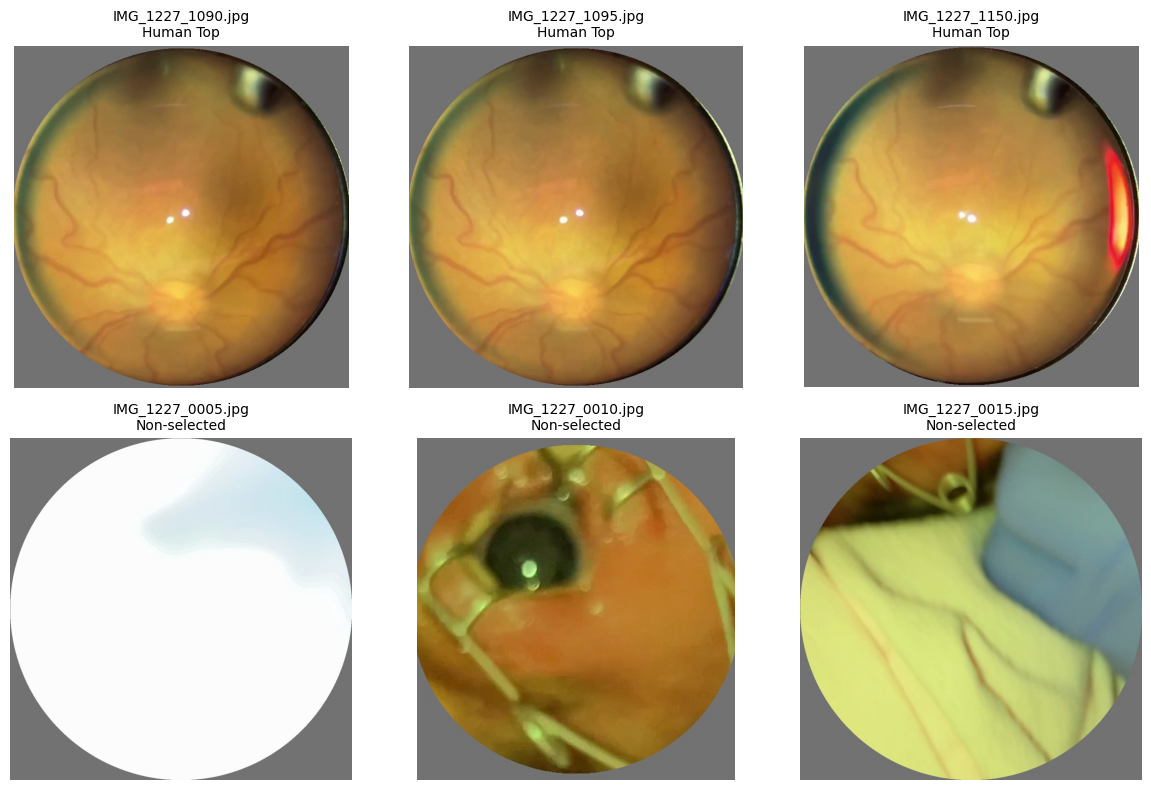

In [29]:
# Verify some cropped images
def show_sample_crops(metadata_df: pd.DataFrame, n_samples: int = 6):
    """Show sample cropped images."""
    # Get samples (mix of human-selected and non-selected)
    human_samples = metadata_df[metadata_df['is_human_top'] == True].head(3)
    other_samples = metadata_df[metadata_df['is_human_top'] == False].head(3)
    samples = pd.concat([human_samples, other_samples])
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for i, (_, row) in enumerate(samples.iterrows()):
        if i >= 6:
            break
        crop_path = row['crop_path']
        if os.path.exists(crop_path):
            img = cv2.imread(crop_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img_rgb)
            title = f"{row['image_name']}\n{'Human Top' if row['is_human_top'] else 'Non-selected'}"
            axes[i].set_title(title, fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

show_sample_crops(metadata_df)

## Section 3: Dataset & DataLoader

In [30]:
# Data augmentation transforms

def get_train_transforms(img_size: int = 384):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Rotate(limit=180, p=0.8, border_mode=cv2.BORDER_CONSTANT, value=(114, 114, 114)),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
        A.GaussianBlur(blur_limit=(3, 7), p=0.3),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                        fill_value=(114, 114, 114), p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_val_transforms(img_size: int = 384):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

print("Transforms defined.")

Transforms defined.


In [31]:
class PairwiseImageDataset(Dataset):
    """
    Dataset for pairwise image ranking.
    Returns (positive_image, negative_image) pairs.
    """
    
    def __init__(self, pairs: List[Dict], transforms=None):
        """
        Args:
            pairs: List of dicts with 'pos_path' and 'neg_path'
            transforms: Albumentations transforms
        """
        self.pairs = pairs
        self.transforms = transforms
    
    def __len__(self) -> int:
        return len(self.pairs)
    
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        pair = self.pairs[idx]
        
        # Load images
        pos_img = cv2.imread(pair['pos_path'])
        neg_img = cv2.imread(pair['neg_path'])
        
        if pos_img is None or neg_img is None:
            # Return dummy data if loading fails
            dummy = torch.zeros(3, 384, 384)
            return {'pos_image': dummy, 'neg_image': dummy}
        
        # Convert BGR to RGB
        pos_img = cv2.cvtColor(pos_img, cv2.COLOR_BGR2RGB)
        neg_img = cv2.cvtColor(neg_img, cv2.COLOR_BGR2RGB)
        
        # Apply transforms
        if self.transforms:
            pos_img = self.transforms(image=pos_img)['image']
            neg_img = self.transforms(image=neg_img)['image']
        
        return {'pos_image': pos_img, 'neg_image': neg_img}


class InferenceDataset(Dataset):
    """
    Dataset for inference (scoring individual images).
    """
    
    def __init__(self, image_paths: List[str], transforms=None):
        self.image_paths = image_paths
        self.transforms = transforms
    
    def __len__(self) -> int:
        return len(self.image_paths)
    
    def __getitem__(self, idx: int) -> Dict:
        path = self.image_paths[idx]
        img = cv2.imread(path)
        
        if img is None:
            return {'image': torch.zeros(3, 384, 384), 'path': path}
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if self.transforms:
            img = self.transforms(image=img)['image']
        
        return {'image': img, 'path': path}


print("Dataset classes defined.")

Dataset classes defined.


In [32]:
def generate_pairwise_samples(
    metadata_df: pd.DataFrame,
    case_ids: List[int],
    num_negatives_per_positive: int = 10,
    hard_negative_ratio: float = 0.5,
    seed: int = 42
) -> List[Dict]:
    """
    Generate pairwise samples for training.
    
    Args:
        metadata_df: DataFrame with crop paths and labels
        case_ids: List of case IDs to include
        num_negatives_per_positive: Number of negative samples per positive
        hard_negative_ratio: Ratio of hard negatives (from high-quality images)
        seed: Random seed
    
    Returns:
        List of dicts with 'pos_path' and 'neg_path'
    """
    np.random.seed(seed)
    pairs = []
    
    for case_id in case_ids:
        case_df = metadata_df[metadata_df['case_id'] == case_id].copy()
        
        # Filter to images with valid crops
        case_df = case_df[case_df['crop_width'] > 100]
        
        positives = case_df[case_df['is_human_top'] == True]
        negatives = case_df[case_df['is_human_top'] == False]
        
        if len(positives) == 0 or len(negatives) == 0:
            continue
        
        for _, pos_row in positives.iterrows():
            pos_path = pos_row['crop_path']
            
            # Sample negatives
            n_neg = min(num_negatives_per_positive, len(negatives))
            neg_samples = negatives.sample(n_neg, random_state=seed)
            
            for _, neg_row in neg_samples.iterrows():
                neg_path = neg_row['crop_path']
                pairs.append({
                    'pos_path': pos_path,
                    'neg_path': neg_path,
                    'case_id': case_id,
                })
    
    return pairs


print("Pair generation function defined.")

Pair generation function defined.


## Section 4: Model定義

In [33]:
class ImagePairwiseRanker(nn.Module):
    """
    Image-based pairwise ranking model using EfficientNet backbone.
    
    Single encoder with shared weights for both positive and negative images.
    """
    
    def __init__(
        self,
        backbone_name: str = "efficientnet_b0",
        pretrained: bool = True,
        head_dims: List[int] = [256],
        dropout: float = 0.5
    ):
        super().__init__()
        
        # Backbone
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,  # Remove classifier
            global_pool='avg'
        )
        
        in_features = self.backbone.num_features  # 1280 for EfficientNet-B0
        
        # Scoring head
        layers = []
        prev_dim = in_features
        for dim in head_dims:
            layers.extend([
                nn.Linear(prev_dim, dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = dim
        layers.append(nn.Linear(prev_dim, 1))
        
        self.head = nn.Sequential(*layers)
        
        # Initialize head weights
        self._init_head_weights()
    
    def _init_head_weights(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward_single(self, x: torch.Tensor) -> torch.Tensor:
        """Score a single image."""
        features = self.backbone(x)
        return self.head(features).squeeze(-1)
    
    def forward(self, pos_images: torch.Tensor, neg_images: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Compute scores for positive and negative images."""
        pos_scores = self.forward_single(pos_images)
        neg_scores = self.forward_single(neg_images)
        return pos_scores, neg_scores
    
    def compute_loss(self, pos_scores: torch.Tensor, neg_scores: torch.Tensor, margin: float = 1.0) -> torch.Tensor:
        """Compute margin ranking loss."""
        return F.margin_ranking_loss(
            pos_scores, neg_scores,
            target=torch.ones_like(pos_scores),
            margin=margin
        )
    
    def freeze_backbone(self):
        """Freeze backbone weights."""
        for param in self.backbone.parameters():
            param.requires_grad = False
    
    def unfreeze_backbone(self, last_n_blocks: int = None):
        """Unfreeze backbone weights."""
        if last_n_blocks is None:
            # Unfreeze all
            for param in self.backbone.parameters():
                param.requires_grad = True
        else:
            # Unfreeze last N blocks (for EfficientNet)
            for name, param in self.backbone.named_parameters():
                param.requires_grad = False
                for i in range(7 - last_n_blocks, 7):
                    if f'blocks.{i}' in name:
                        param.requires_grad = True
                        break


# Test model creation
test_model = ImagePairwiseRanker("efficientnet_b0", pretrained=True)
print(f"Model created. Backbone features: {test_model.backbone.num_features}")
del test_model

Model created. Backbone features: 1280


## Section 5: Trainer

In [34]:
class EarlyStopping:
    """Early stopping to prevent overfitting."""
    
    def __init__(self, patience: int = 10, min_delta: float = 0.0, mode: str = 'min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_value = None
        self.should_stop = False
    
    def __call__(self, value: float) -> bool:
        if self.best_value is None:
            self.best_value = value
            return False
        
        if self.mode == 'min':
            improved = value < self.best_value - self.min_delta
        else:
            improved = value > self.best_value + self.min_delta
        
        if improved:
            self.best_value = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                return True
        
        return False


print("EarlyStopping class defined.")

EarlyStopping class defined.


In [35]:
class Trainer:
    """Trainer for image-based pairwise ranking model."""
    
    def __init__(
        self,
        model: ImagePairwiseRanker,
        config: Config,
        device: torch.device = None
    ):
        self.model = model
        self.config = config
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self.model.to(self.device)
        
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay
        )
        
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=0.5,
            patience=5
        )
        
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'lr': []
        }
    
    def train_epoch(self, train_loader: DataLoader) -> Tuple[float, float]:
        """Train for one epoch."""
        self.model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
        
        for batch in train_loader:
            pos_images = batch['pos_image'].to(self.device)
            neg_images = batch['neg_image'].to(self.device)
            
            self.optimizer.zero_grad()
            
            pos_scores, neg_scores = self.model(pos_images, neg_images)
            loss = self.model.compute_loss(pos_scores, neg_scores, self.config.margin)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            total_loss += loss.item() * pos_images.size(0)
            
            # Compute accuracy
            with torch.no_grad():
                correct = (pos_scores > neg_scores).sum().item()
                total_correct += correct
                total_samples += pos_images.size(0)
        
        avg_loss = total_loss / total_samples
        accuracy = total_correct / total_samples
        
        return avg_loss, accuracy
    
    def fit(
        self,
        train_loader: DataLoader,
        num_epochs: int = None,
        verbose: bool = True
    ) -> Dict:
        """Train the model."""
        num_epochs = num_epochs or self.config.num_epochs
        early_stopper = EarlyStopping(patience=self.config.early_stopping_patience)
        best_loss = float('inf')
        best_state = None
        
        epoch_iter = tqdm(range(num_epochs), desc='Training') if verbose else range(num_epochs)
        
        for epoch in epoch_iter:
            train_loss, train_acc = self.train_epoch(train_loader)
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            
            self.scheduler.step(train_loss)
            current_lr = self.optimizer.param_groups[0]['lr']
            self.history['lr'].append(current_lr)
            
            if train_loss < best_loss:
                best_loss = train_loss
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
            
            if early_stopper(train_loss):
                if verbose:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                break
            
            if verbose and hasattr(epoch_iter, 'set_description'):
                epoch_iter.set_description(f"Loss={train_loss:.4f}, Acc={train_acc:.4f}")
        
        if best_state:
            self.model.load_state_dict(best_state)
        
        return self.history


print("Trainer class defined.")

Trainer class defined.


In [36]:
def evaluate_case(
    model: ImagePairwiseRanker,
    metadata_df: pd.DataFrame,
    case_id: int,
    transforms,
    device: torch.device,
    k: int = 5
) -> Dict:
    """
    Evaluate model on a single case.
    
    Returns metrics including Top-K precision, recall, MRR.
    """
    model.eval()
    
    # Get case data
    case_df = metadata_df[metadata_df['case_id'] == case_id].copy()
    case_df = case_df[case_df['crop_width'] > 100]  # Valid crops only
    
    if len(case_df) == 0:
        return {'case_id': case_id, 'error': 'No valid images'}
    
    # Score all images
    image_paths = case_df['crop_path'].tolist()
    dataset = InferenceDataset(image_paths, transforms)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    all_scores = []
    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            scores = model.forward_single(images)
            all_scores.extend(scores.cpu().numpy().tolist())
    
    case_df['predicted_score'] = all_scores
    
    # Get AI top-k
    ai_top_k = case_df.nlargest(k, 'predicted_score')['image_name'].tolist()
    
    # Get human selections
    human_top = case_df[case_df['is_human_top'] == True]['image_name'].tolist()
    
    # Compute metrics
    matches = len(set(ai_top_k) & set(human_top))
    
    # MRR
    sorted_df = case_df.sort_values('predicted_score', ascending=False).reset_index(drop=True)
    mrr = 0.0
    for rank, row in enumerate(sorted_df.itertuples(), 1):
        if row.is_human_top:
            mrr = 1.0 / rank
            break
    
    # NDCG@k
    relevance = sorted_df['is_human_top'].astype(int).values[:k]
    dcg = sum((2 ** rel - 1) / np.log2(i + 2) for i, rel in enumerate(relevance))
    ideal_relevance = sorted(case_df['is_human_top'].astype(int).values, reverse=True)[:k]
    idcg = sum((2 ** rel - 1) / np.log2(i + 2) for i, rel in enumerate(ideal_relevance))
    ndcg = dcg / idcg if idcg > 0 else 0.0
    
    return {
        'case_id': case_id,
        'top5_precision': matches / k,
        'top5_recall': matches / len(human_top) if human_top else 0,
        'video_match': 1 if matches > 0 else 0,
        'ndcg_at_5': ndcg,
        'mrr': mrr,
        'ai_top_k': ai_top_k,
        'human_top': human_top,
        'num_matches': matches,
        'n_human_in_candidates': len(human_top),
    }


print("Evaluation function defined.")

Evaluation function defined.


In [37]:
def run_lovo_cv_v2(
    metadata_df: pd.DataFrame,
    config: Config,
    num_folds: int = None,
    num_epochs: int = None,
    freeze_backbone: bool = False,  # Default to NOT freeze
    backbone_lr: float = 1e-5,      # Lower LR for backbone
    head_lr: float = 1e-3,          # Higher LR for head
    early_stopping_patience: int = 10,  # Early stopping
    verbose: bool = True
) -> Dict:
    """
    Run Leave-One-Video-Out cross-validation with improved training.
    
    Key improvements:
    - Backbone unfrozen by default (fine-tuning)
    - Differential learning rates for backbone vs head
    - Early stopping with patience=10
    - Training logs for each fold
    """
    results = {
        'case_id': [],
        'top5_precision': [],
        'top5_recall': [],
        'video_match': [],
        'ndcg_at_5': [],
        'mrr': [],
        'n_human_in_candidates': [],
        'training_history': [],  # Store training logs
        'stopped_epoch': [],      # When training stopped
    }
    
    case_ids = sorted(metadata_df['case_id'].unique())
    case_ids_to_eval = case_ids[:num_folds] if num_folds else case_ids
    epochs = num_epochs or config.num_epochs
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"LOVO CV v2: {len(case_ids_to_eval)} folds, {epochs} epochs each")
        print(f"Backbone frozen: {freeze_backbone}")
        print(f"Backbone LR: {backbone_lr}, Head LR: {head_lr}")
        print(f"Early stopping patience: {early_stopping_patience}")
        print(f"{'='*60}")
    
    train_transforms = get_train_transforms(config.img_size)
    val_transforms = get_val_transforms(config.img_size)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    for fold_idx, test_case_id in enumerate(case_ids_to_eval):
        if verbose:
            print(f"\n--- Fold {fold_idx+1}/{len(case_ids_to_eval)}: Test case {test_case_id} ---")
        
        # Train/test split
        train_case_ids = [cid for cid in case_ids if cid != test_case_id]
        
        # Generate training pairs
        train_pairs = generate_pairwise_samples(
            metadata_df, train_case_ids,
            num_negatives_per_positive=config.num_negatives_per_positive,
            seed=config.seed
        )
        
        if len(train_pairs) == 0:
            if verbose:
                print(f"  WARNING: No training pairs for fold {test_case_id}, skipping")
            continue
        
        if verbose:
            print(f"  Training pairs: {len(train_pairs)}")
        
        # Create dataset and loader
        train_dataset = PairwiseImageDataset(train_pairs, train_transforms)
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=True,
            num_workers=0
        )
        
        # Create model
        model = ImagePairwiseRanker(
            config.backbone,
            pretrained=config.pretrained,
            head_dims=config.head_hidden_dims,
            dropout=config.dropout
        )
        model = model.to(device)
        
        if freeze_backbone:
            model.freeze_backbone()
            optimizer = optim.AdamW(
                model.head.parameters(),
                lr=head_lr,
                weight_decay=config.weight_decay
            )
        else:
            # Differential learning rates
            optimizer = optim.AdamW([
                {'params': model.backbone.parameters(), 'lr': backbone_lr},
                {'params': model.head.parameters(), 'lr': head_lr}
            ], weight_decay=config.weight_decay)
        
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        
        # Early stopping
        early_stopper = EarlyStopping(patience=early_stopping_patience, mode='min')
        
        # Training history for this fold
        fold_history = {
            'epoch': [],
            'loss': [],
            'accuracy': [],
            'lr': []
        }
        
        # Training loop
        best_loss = float('inf')
        best_state = None
        stopped_epoch = epochs
        
        for epoch in range(epochs):
            model.train()
            total_loss = 0.0
            total_correct = 0
            total_samples = 0
            
            for batch in train_loader:
                pos_images = batch['pos_image'].to(device)
                neg_images = batch['neg_image'].to(device)
                
                optimizer.zero_grad()
                pos_scores, neg_scores = model(pos_images, neg_images)
                loss = model.compute_loss(pos_scores, neg_scores, config.margin)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
                total_loss += loss.item() * pos_images.size(0)
                with torch.no_grad():
                    correct = (pos_scores > neg_scores).sum().item()
                    total_correct += correct
                    total_samples += pos_images.size(0)
            
            avg_loss = total_loss / total_samples
            train_acc = total_correct / total_samples
            current_lr = optimizer.param_groups[0]['lr']
            scheduler.step()
            
            # Record history
            fold_history['epoch'].append(epoch + 1)
            fold_history['loss'].append(avg_loss)
            fold_history['accuracy'].append(train_acc)
            fold_history['lr'].append(current_lr)
            
            # Print progress every 10 epochs or at end
            if verbose and (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1:3d}: Loss={avg_loss:.4f}, Acc={train_acc:.4f}, LR={current_lr:.2e}")
            
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
            # Check early stopping
            if early_stopper(avg_loss):
                stopped_epoch = epoch + 1
                if verbose:
                    print(f"  Early stopping at epoch {stopped_epoch}")
                break
        
        # Print final training stats
        if verbose:
            print(f"  Final: Loss={fold_history['loss'][-1]:.4f}, Acc={fold_history['accuracy'][-1]:.4f}")
        
        # Restore best model
        if best_state:
            model.load_state_dict(best_state)
        
        # Evaluate
        metrics = evaluate_case(
            model, metadata_df, test_case_id,
            val_transforms, device, k=config.top_k_eval
        )
        
        if verbose:
            print(f"  Eval: Top5 Prec={metrics['top5_precision']:.2f}, MRR={metrics['mrr']:.3f}")
        
        results['case_id'].append(test_case_id)
        for key in ['top5_precision', 'top5_recall', 'video_match', 'ndcg_at_5', 'mrr', 'n_human_in_candidates']:
            results[key].append(metrics.get(key, 0))
        results['training_history'].append(fold_history)
        results['stopped_epoch'].append(stopped_epoch)
        
        # Clean up
        del model, optimizer
        torch.cuda.empty_cache()
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"LOVO CV v2 Results ({len(case_ids_to_eval)} folds)")
        print(f"{'='*60}")
        print(f"Mean Top-5 Precision: {np.mean(results['top5_precision']):.4f}")
        print(f"Mean Top-5 Recall: {np.mean(results['top5_recall']):.4f}")
        print(f"Video Match Rate: {np.mean(results['video_match']):.4f}")
        print(f"Mean NDCG@5: {np.mean(results['ndcg_at_5']):.4f}")
        print(f"Mean MRR: {np.mean(results['mrr']):.4f}")
        print(f"Avg stopped epoch: {np.mean(results['stopped_epoch']):.1f}")
    
    return results


print("LOVO CV v2 function defined (with backbone fine-tuning + early stopping + training logs).")

LOVO CV v2 function defined (with backbone fine-tuning + early stopping + training logs).


## Section 6: パイロットテスト

3 fold, 10 epochsで動作確認

In [38]:
# Load metadata if not already loaded
if 'metadata_df' not in dir() or metadata_df is None:
    metadata_path = config.lens_crops_dir / 'metadata.csv'
    if metadata_path.exists():
        metadata_df = pd.read_csv(metadata_path)
        print(f"Loaded metadata: {len(metadata_df)} images")
    else:
        print("ERROR: Lens crops metadata not found. Run Section 2 first.")

In [39]:
# Check data summary
print(f"Total images: {len(metadata_df)}")
print(f"Images with lens detected: {metadata_df['has_lens'].sum()}")
print(f"Human-selected images: {metadata_df['is_human_top'].sum()}")
print(f"Number of cases: {metadata_df['case_id'].nunique()}")
print(f"\nCase IDs: {sorted(metadata_df['case_id'].unique())}")

Total images: 6689
Images with lens detected: 6037
Human-selected images: 138
Number of cases: 22

Case IDs: [1227, 1363, 1376, 1601, 1632, 1703, 1732, 1891, 1966, 2024, 2026, 2028, 2116, 2168, 2232, 2289, 2290, 2356, 2358, 2376, 2403, 2431]


In [40]:
# Pilot test v2: Backbone fine-tuning with differential learning rates
# Increased epochs and folds for better evaluation
print("Starting pilot test v2 (5 folds, 50 epochs, backbone fine-tuning)...")
print("This will take longer but should learn better...")

pilot_results_v2 = run_lovo_cv_v2(
    metadata_df,
    config,
    num_folds=5,        # More folds for better estimate
    num_epochs=50,      # More epochs for convergence
    freeze_backbone=False,  # Fine-tune backbone
    backbone_lr=1e-5,   # Lower LR for backbone
    head_lr=1e-3,       # Higher LR for head
    early_stopping_patience=10,
    verbose=True
)

Starting pilot test v2 (5 folds, 50 epochs, backbone fine-tuning)...
This will take longer but should learn better...

LOVO CV v2: 5 folds, 50 epochs each
Backbone frozen: False
Backbone LR: 1e-05, Head LR: 0.001
Early stopping patience: 10

--- Fold 1/5: Test case 1227 ---
  Training pairs: 1320
  Epoch  10: Loss=0.0217, Acc=0.9947, LR=9.22e-06
  Epoch  20: Loss=0.0022, Acc=1.0000, LR=6.84e-06
  Epoch  30: Loss=0.0013, Acc=0.9992, LR=3.76e-06
  Early stopping at epoch 38
  Final: Loss=0.0010, Acc=1.0000
  Eval: Top5 Prec=0.00, MRR=0.015

--- Fold 2/5: Test case 1363 ---
  Training pairs: 1320
  Epoch  10: Loss=0.0247, Acc=0.9909, LR=9.22e-06
  Epoch  20: Loss=0.0082, Acc=0.9970, LR=6.84e-06
  Epoch  30: Loss=0.0015, Acc=0.9992, LR=3.76e-06
  Epoch  40: Loss=0.0004, Acc=1.0000, LR=1.15e-06
  Epoch  50: Loss=0.0013, Acc=0.9992, LR=9.87e-09
  Final: Loss=0.0013, Acc=0.9992
  Eval: Top5 Prec=0.00, MRR=0.013

--- Fold 3/5: Test case 1376 ---
  Training pairs: 1320
  Epoch  10: Loss=0.0242,

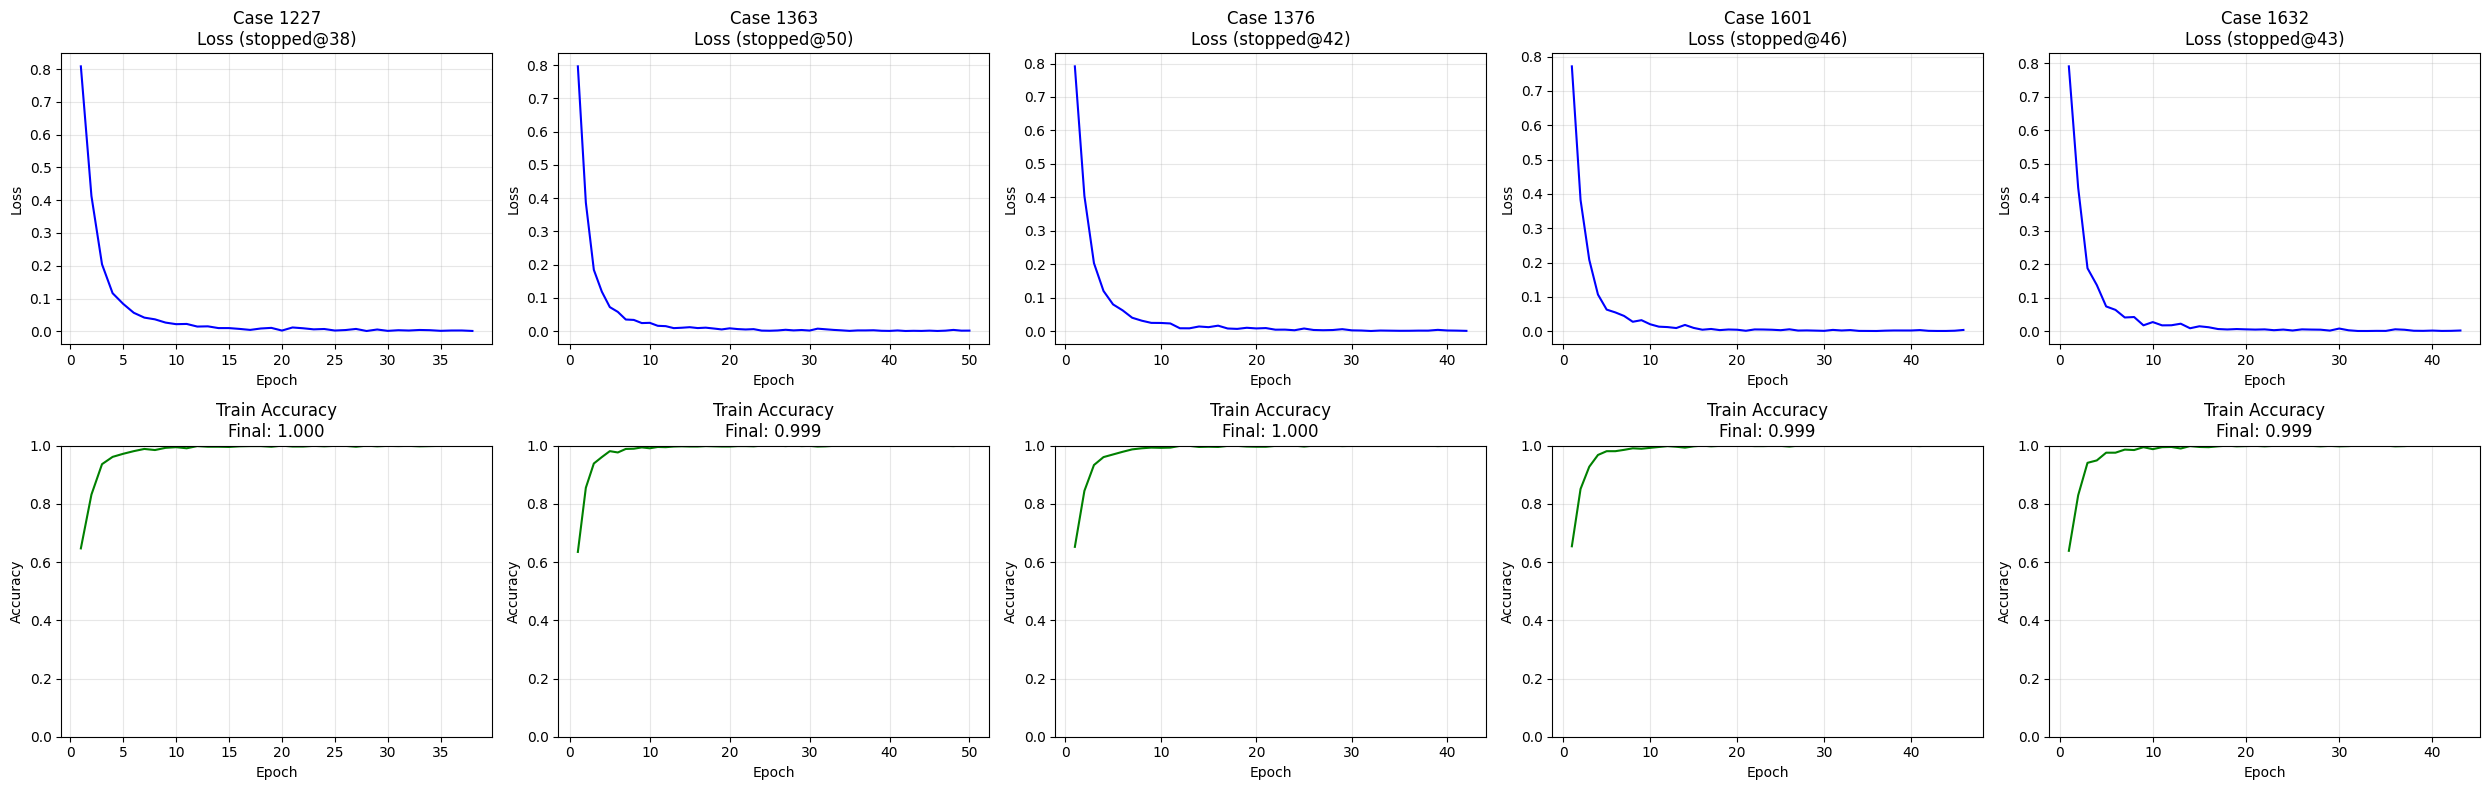


COMPARISON WITH BASELINE
Baseline Top-5 Precision: 0.4730
Model Top-5 Precision:    0.0000
Improvement:              -100.0%

Per-case results:
 case_id  top5_precision  top5_recall  video_match      mrr  stopped_epoch
    1227             0.0          0.0            0 0.015152             38
    1363             0.0          0.0            0 0.013333             50
    1376             0.0          0.0            0 0.047619             42
    1601             0.0          0.0            0 0.011765             46
    1632             0.0          0.0            0 0.066667             43


In [41]:
# Plot training curves for each fold
def plot_training_curves(results: Dict):
    """Plot loss and accuracy curves for each fold."""
    n_folds = len(results['training_history'])
    
    fig, axes = plt.subplots(2, n_folds, figsize=(5*n_folds, 8))
    if n_folds == 1:
        axes = axes.reshape(-1, 1)
    
    for i, (case_id, history) in enumerate(zip(results['case_id'], results['training_history'])):
        epochs = history['epoch']
        
        # Loss
        axes[0, i].plot(epochs, history['loss'], 'b-', label='Loss')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].set_title(f'Case {case_id}\nLoss (stopped@{results["stopped_epoch"][i]})')
        axes[0, i].grid(True, alpha=0.3)
        
        # Accuracy
        axes[1, i].plot(epochs, history['accuracy'], 'g-', label='Accuracy')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Accuracy')
        axes[1, i].set_title(f'Train Accuracy\nFinal: {history["accuracy"][-1]:.3f}')
        axes[1, i].set_ylim([0, 1])
        axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot training curves
if 'training_history' in pilot_results_v2:
    plot_training_curves(pilot_results_v2)

# Compare with baseline
print("\n" + "="*60)
print("COMPARISON WITH BASELINE")
print("="*60)

baseline_precision = 0.473  # From previous experiment
model_precision = np.mean(pilot_results_v2['top5_precision'])

print(f"Baseline Top-5 Precision: {baseline_precision:.4f}")
print(f"Model Top-5 Precision:    {model_precision:.4f}")
print(f"Improvement:              {(model_precision - baseline_precision) / baseline_precision * 100:+.1f}%")

# Per-case results
print("\n" + "="*60)
print("Per-case results:")
print("="*60)
results_df_v2 = pd.DataFrame({
    'case_id': pilot_results_v2['case_id'],
    'top5_precision': pilot_results_v2['top5_precision'],
    'top5_recall': pilot_results_v2['top5_recall'],
    'video_match': pilot_results_v2['video_match'],
    'mrr': pilot_results_v2['mrr'],
    'stopped_epoch': pilot_results_v2['stopped_epoch'],
})
print(results_df_v2.to_string(index=False))

## Section 7: フルCV（オプション）

パイロットテストが良好な場合、22 fold完全CVを実行

In [42]:
# Uncomment to run full CV
# print("Starting full CV (22 folds, 30 epochs)...")
# 
# full_results = run_lovo_cv(
#     metadata_df,
#     config,
#     num_folds=None,  # All folds
#     num_epochs=30,
#     verbose=True
# )

## Section 8: 結果分析

In [43]:
# Plot results (if full CV was run)
def plot_results(results: Dict):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Top-5 Precision per case
    axes[0].bar(range(len(results['case_id'])), results['top5_precision'])
    axes[0].axhline(y=0.473, color='r', linestyle='--', label='Baseline')
    axes[0].set_xlabel('Case Index')
    axes[0].set_ylabel('Top-5 Precision')
    axes[0].set_title('Top-5 Precision per Case')
    axes[0].legend()
    
    # Video Match
    axes[1].bar(range(len(results['case_id'])), results['video_match'])
    axes[1].set_xlabel('Case Index')
    axes[1].set_ylabel('Video Match (0/1)')
    axes[1].set_title('Video Match per Case')
    
    # MRR
    axes[2].bar(range(len(results['case_id'])), results['mrr'])
    axes[2].set_xlabel('Case Index')
    axes[2].set_ylabel('MRR')
    axes[2].set_title('MRR per Case')
    
    plt.tight_layout()
    plt.show()

# Plot pilot results
plot_results(pilot_results)

NameError: name 'pilot_results' is not defined

In [ ]:
# Summary table
results_df = pd.DataFrame(pilot_results)
print("\nPer-case results:")
print(results_df.to_string(index=False))

print("\nSummary statistics:")
print(results_df.describe())


Per-case results:
 case_id  top5_precision  top5_recall  video_match  ndcg_at_5      mrr  n_human_in_candidates
    1227             0.0          0.0            0        0.0 0.052632                      6
    1363             0.0          0.0            0        0.0 0.010309                      6
    1376             0.0          0.0            0        0.0 0.166667                      6

Summary statistics:
           case_id  top5_precision  top5_recall  video_match  ndcg_at_5  \
count     3.000000             3.0          3.0          3.0        3.0   
mean   1322.000000             0.0          0.0          0.0        0.0   
std      82.528783             0.0          0.0          0.0        0.0   
min    1227.000000             0.0          0.0          0.0        0.0   
25%    1295.000000             0.0          0.0          0.0        0.0   
50%    1363.000000             0.0          0.0          0.0        0.0   
75%    1369.500000             0.0          0.0          0.